# 07 — Surprise and DTW on ES, NQ and ZN: A Multi-Market Event Book

## Purpose

Notebooks 04–06 traded **ES only**. The supervisor asked us to apply the same signals to two more futures markets:

| Market | Contract | Why it should react to macro surprises |
|---|---|---|
| **ES** | E-mini S&P 500 | Equities: growth and discount-rate news |
| **NQ** | E-mini Nasdaq-100 | Tech-heavy equities, usually **more** rate-sensitive than ES |
| **ZN** | 10-year US Treasury note | Bonds: the **most direct** channel for inflation and policy surprises (yields move, prices move the other way) |

**Questions:**
1. Does the surprise strategy (Notebook 05) work on NQ and ZN, after each market's own costs?
2. Does DTW (Notebook 06) help on any of them?
3. Does a **three-market portfolio** raise the trade count and the Sharpe through diversification?

**Credits:** the NQ and ZN 1-minute data were pulled and cleaned by **Jack Duncan** (`blackrock-intraday/combined/cleaning.py`), and the contract specifications come from his `combined/config.py`. His multi-asset DTW book (ES, NQ, ZN) is the peer benchmark for this notebook.

## Methodology: fixed before looking at results

- **The same pipeline as Notebooks 05–06, run separately for each market:** entry at the close of the first post-release bar (T+1), exit 30 minutes after the release, walk-forward evaluation over 2019–2026, with 2016–2018 as history.
- **Each market has its own impact screen and its own signs.** Markets react to different releases, and in different directions: a strong payrolls print usually pushes **ES and NQ up** but **ZN down** (yields rise). The signs are estimated from each market's own jump reaction, on history only.
- **Costs are in each market's own ticks:** 2 ticks round trip plus $4.50 per contract. One ZN tick is large relative to its moves, so costs matter most there.

| Market | Tick | $ per point | $ per tick | ≈ 2-tick round trip |
|---|---|---|---|---|
| ES | 0.25 | 50 | 12.50 | ~1.4 bps |
| NQ | 0.25 | 20 | 5.00 | ~0.5–1 bps |
| ZN | 1/64 | 1,000 | 15.63 | ~2.8 bps |

- **Strategies per market:** CPI surprise model; multi-release naive surprise ("All · naive"); DTW only; surprise + DTW agreement (all releases and CPI).
- **Portfolio:** the markets are combined at **equal risk**, with weights from 2016–2018 history only (inverse volatility of each market's 30-minute release-window return).
- **Data:** ES uses this project's file, so ES reproduces Notebook 05 exactly (checked below). NQ and ZN use Jack's cleaned files from the team repo.

## 1. Setup and Project Paths

In [1]:
from pathlib import Path
import sys, importlib, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
for d in [RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# team repo (Jack Duncan's cleaned NQ and ZN files) sits next to this project
TEAM_DATA = PROJECT_ROOT.parent / "blackrock-intraday" / "data" / "processed"
BBG_FILE = RAW_DIR / "Bloomberg Economic Releases.xlsx"
MARKETS = {
    "ES": (RAW_DIR / "ES_1m_2010_2026_full.parquet", "project"),
    "NQ": (TEAM_DATA / "futures_1min_clean_v3_NQ.parquet", "team_v3"),
    "ZN": (TEAM_DATA / "futures_1min_clean_v3_ZN.parquet", "team_v3"),
}
NB05_LOG = RESULTS_DIR / "nb05_trade_log.csv"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import src.state_conditioning as sc
import src.walk_forward as wf
import src.surprise_universe as su
import src.dtw_signal as ds
import src.multi_asset as ma
for m in (sc, wf, su, ds, ma):
    importlib.reload(m)

for sym, (f, kind) in MARKETS.items():
    print(f"{sym}: {f}  exists: {f.exists()}")
print("Bloomberg:", BBG_FILE.exists(), "| NB05 trade log:", NB05_LOG.exists())

ES: /Users/reza/Desktop/mfe-term_3/BlackRock-Project-State-Dependent-Intraday-Response-of-S-P-500-Futures-to-Macroeconomic-Surprises/data/raw/ES_1m_2010_2026_full.parquet  exists: True
NQ: /Users/reza/Desktop/mfe-term_3/blackrock-intraday/data/processed/futures_1min_clean_v3_NQ.parquet  exists: True
ZN: /Users/reza/Desktop/mfe-term_3/blackrock-intraday/data/processed/futures_1min_clean_v3_ZN.parquet  exists: True
Bloomberg: True | NB05 trade log: True


### 1.1 Pre-registered parameters

In [2]:
HIST_START = "2016-01-01"
EVAL_START, EVAL_END = "2019-01-01", "2026-06-30"
EVAL_YEARS = list(range(2019, 2027))
N_YEARS = (pd.Timestamp(EVAL_END) - pd.Timestamp(EVAL_START)).days / 365.25
K_FAMILIES, MIN_TRAIN, THRESHOLD = 10, 24, 1.0
TICKS_RT, COMMISSION_RT = 2.0, 4.5
N_NULL, N_BOOT = 1000, 5000
STRATS = ["CPI · surprise model", "All · naive", "All · DTW only", "All · surprise + DTW agree", "CPI · surprise + DTW agree"]

## 2. Releases, Families and Surprises (as in Notebook 05)

In [3]:
rows = su.load_bloomberg(BBG_FILE)
fam = su.build_families(rows)
surp = su.standardise_surprises(rows)
surp = surp[surp["ticker"].isin(fam["ticker"])]
print(f"Release rows: {len(rows):,} | families: {fam['family'].nunique()} | surprises with a z-score: {surp['z'].notna().sum():,}")

Release rows: 27,137 | families: 75 | surprises with a z-score: 17,328


## 3. Run the Full Pipeline for Each Market

Each market is loaded, roll-adjusted, screened, signed and traded independently. This takes about 1–3 minutes per market.

In [4]:
results, adj_by = {}, {}
for sym, (path, kind) in MARKETS.items():
    t0 = time.time()
    bars = ma.load_bars(path, kind)
    adj_by[sym] = ma.adjusted(bars)
    results[sym] = ma.run_market(sym, adj_by[sym], rows, fam, surp, hist_start=HIST_START,
                                 eval_start=EVAL_START, eval_end=EVAL_END, eval_years=EVAL_YEARS,
                                 k_families=K_FAMILIES, min_train=MIN_TRAIN, threshold=THRESHOLD,
                                 ticks_rt=TICKS_RT, commission_rt=COMMISSION_RT)
    print(f"   {sym} bars: {len(bars):,} ({bars.index.min().date()} to {bars.index.max().date()}) | {time.time()-t0:.0f}s")

cov = pd.DataFrame({sym: r["px"].assign(y=r["px"]["ts_utc"].dt.year).groupby("y")["w1"].apply(lambda v: v.notna().mean())
                    for sym, r in results.items()})
print("\nShare of release timestamps with a complete 30-minute trade window, by year:")
display(cov.round(3).T)

ES: 6,097 release timestamps, 5,920 with a trade return, avg cost 1.57 bps, DTW for 5,181 releases
   ES bars: 4,811,336 (2010-07-01 to 2026-06-30) | 6s
NQ: 6,097 release timestamps, 5,852 with a trade return, avg cost 0.61 bps, DTW for 5,229 releases
   NQ bars: 5,255,764 (2010-07-01 to 2026-06-30) | 6s
ZN: 6,097 release timestamps, 5,878 with a trade return, avg cost 2.93 bps, DTW for 5,244 releases
   ZN bars: 5,392,031 (2010-07-01 to 2026-06-30) | 6s

Share of release timestamps with a complete 30-minute trade window, by year:


y,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
ES,0.971,0.965,0.966,0.964,0.961,0.988,0.983,0.986,0.984,0.993,0.892
NQ,0.922,0.940,0.958,0.969,0.968,0.997,0.983,0.971,0.963,0.979,0.887
ZN,0.950,0.952,0.961,0.971,0.961,0.972,0.994,0.977,0.982,0.973,0.887


### 3.1 Validation: ES must reproduce Notebook 05

In [5]:
log5 = pd.read_csv(NB05_LOG)
log5["timestamp_utc"] = pd.to_datetime(log5["timestamp_utc"], utc=True)
for s in ["All · naive", "CPI · surprise model"]:
    a = log5[log5["strategy"] == s].set_index("timestamp_utc")["net_bps"]
    b = results["ES"]["trades"][s].set_index("timestamp_utc")["net_bps"]
    j = pd.concat([a, b], axis=1, keys=["nb05", "nb07"]).dropna()
    print(f"{s:<24s} common releases {len(j)} / NB05 {len(a)} | max |diff| = {(j.nb05 - j.nb07).abs().max():.2e} bps")
    assert (j.nb05 - j.nb07).abs().max() < 1e-6, "ES does not reproduce Notebook 05"
print("PASSED: ES reproduces Notebook 05 exactly")

All · naive              common releases 809 / NB05 809 | max |diff| = 1.42e-14 bps
CPI · surprise model     common releases 89 / NB05 89 | max |diff| = 3.55e-15 bps
PASSED: ES reproduces Notebook 05 exactly


### 3.2 Do the markets react to CPI in the expected directions?

In [6]:
cpi_ts = surp[surp["ticker"] == "CPI CHNG Index"][["ts_utc", "z"]].dropna()
cpi_ts = cpi_ts[(cpi_ts["ts_utc"] >= pd.Timestamp(EVAL_START, tz="UTC"))]
jumps = pd.DataFrame({sym: cpi_ts["ts_utc"].map(r["px"].set_index("ts_utc")["jump"]).to_numpy()
                      for sym, r in results.items()}, index=cpi_ts["ts_utc"])
jumps["CPI MoM surprise z"] = cpi_ts["z"].to_numpy()
print("Correlation of the instant jump with the CPI MoM surprise, and across markets (2019-2026):")
display(jumps.corr().round(2))

sign_tab = pd.DataFrame({sym: r["signs"][EVAL_YEARS[0]] for sym, r in results.items()})
key = {"CPI CHNG Index": "CPI MoM", "CPUPXCHG Index": "Core CPI MoM", "NFP TCH Index": "Nonfarm payrolls",
       "USURTOT Index": "Unemployment rate", "RSTAMOM Index": "Retail sales", "NAPMPMI Index": "ISM Manufacturing"}
print("Line signs estimated on 2016-2018 (+1: a positive surprise pushed the price up):")
display(sign_tab.reindex(list(key)).rename(index=key))

Correlation of the instant jump with the CPI MoM surprise, and across markets (2019-2026):


,ES,NQ,ZN,CPI MoM surprise z
ES,1.000,0.980,0.870,-0.580
NQ,0.980,1.000,0.860,-0.600
ZN,0.870,0.860,1.000,-0.600
CPI MoM surprise z,-0.580,-0.600,-0.600,1.000


Line signs estimated on 2016-2018 (+1: a positive surprise pushed the price up):


,ES,NQ,ZN
CPI MoM,-1.000,-1.000,-1.000
Core CPI MoM,-1.000,-1.000,-1.000
Nonfarm payrolls,1.000,1.000,-1.000
Unemployment rate,1.000,1.000,-1.000
Retail sales,1.000,1.000,-1.000
ISM Manufacturing,1.000,1.000,-1.000


**Expected pattern.** A hot CPI print should push **all three markets down**: stocks fall and bond prices fall as yields rise. A strong payrolls print should push **ES and NQ up** but **ZN down**. If the signs look like this, each market's signal is set up correctly.

## 4. Which Releases Does Each Market React To?

In [7]:
adm = {}
for sym, r in results.items():
    ranks = pd.DataFrame({y: r["screens"][y].set_index("family")["rank"] for y in EVAL_YEARS})
    adm[sym] = ranks[(ranks <= K_FAMILIES).any(axis=1)].sort_values(EVAL_YEARS[-1])
    print(f"\n=== {sym}: families admitted (top {K_FAMILIES}) in at least one year — rank by year ===")
    display(adm[sym].astype("Int64"))


=== ES: families admitted (top 10) in at least one year — rank by year ===


,2019,2020,2021,2022,2023,2024,2025,2026
family,,,,,,,,
CPI,2,4,5,3,1,1,1,1
Employment Report (NFP),1,1,1,1,4,3,3,2
Fed Interest on Reserve Balances Rate,<NA>,<NA>,<NA>,<NA>,2,2,2,3
FOMC Rate Decision,<NA>,2,2,2,3,4,4,4
ISM Manufacturing,8,6,12,13,5,8,6,5
U. of Michigan Sentiment,22,25,22,16,7,6,7,6
ISM Services,5,7,7,7,6,5,5,7
JOLTS,13,15,8,9,11,7,8,8
Dallas Fed Manf. Activity,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,9



=== NQ: families admitted (top 10) in at least one year — rank by year ===


,2019,2020,2021,2022,2023,2024,2025,2026
family,,,,,,,,
CPI,<NA>,3,2,1,1,1,1,1
Employment Report (NFP),1,1,1,2,4,3,3,2
Fed Interest on Reserve Balances Rate,<NA>,<NA>,<NA>,<NA>,2,2,2,3
FOMC Rate Decision,<NA>,<NA>,3,3,3,4,4,4
Dallas Fed Manf. Activity,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,5
ISM Services,5,8,7,9,5,5,5,6
ISM Manufacturing,4,5,11,14,8,9,6,7
U. of Michigan Sentiment,24,29,20,15,7,6,7,8
PPI,14,19,9,8,13,12,10,9



=== ZN: families admitted (top 10) in at least one year — rank by year ===


,2019,2020,2021,2022,2023,2024,2025,2026
family,,,,,,,,
FOMC Rate Decision,<NA>,1,1,1,1,1,1,1
ISM Services Prices Paid,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2
Employment Report (NFP),1,2,2,2,3,3,3,3
CPI,3,6,6,5,2,2,2,4
Fed Interest on Reserve Balances Rate,<NA>,<NA>,<NA>,<NA>,5,4,4,5
ISM Services,4,5,5,4,6,6,5,6
ISM New Orders,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,7
ISM Manufacturing,<NA>,3,3,3,4,5,6,8
S&P Global US Manufacturing PMI,10,8,8,8,8,7,7,9


## 5. Performance by Market (2019–2026, net of costs)

In [8]:
def sharpe_m(tr, a, b, drop_year=None):
    m = wf.monthly_returns(tr, a, b)
    if drop_year:
        m = m[m.index.year != drop_year]
    sd = m.std(ddof=1)
    return m.mean() / sd * np.sqrt(12) if sd > 0 else np.nan

rows_p = []
for sym, r in results.items():
    for s in STRATS:
        t = r["trades"][s]
        p = wf.performance(t, EVAL_START, EVAL_END, s)
        _, p_null = su.random_sign_pvalue(t, wf.monthly_returns, EVAL_START, EVAL_END, n=N_NULL)
        rows_p.append(dict(market=sym, strategy=s, trades_per_year=p["trades"] / N_YEARS, hit_rate=p["hit_rate"],
                           avg_cost_bps=p["avg_cost_bps"], avg_net_bps=p["avg_net_bps"], total_net_pct=p["total_net_pct"],
                           sharpe_gross=p["sharpe_gross"], sharpe_net=p["sharpe_net"],
                           sharpe_2019_21=sharpe_m(t, "2019-01-01", "2021-12-31"),
                           sharpe_2022_26=sharpe_m(t, "2022-01-01", EVAL_END),
                           sharpe_ex_2022=sharpe_m(t, EVAL_START, EVAL_END, 2022),
                           max_dd_pct=p["max_dd_pct"], p_random_sign=p_null))
perf = pd.DataFrame(rows_p).set_index(["market", "strategy"])
perf.to_csv(RESULTS_DIR / "nb07_performance_by_market.csv")
display(perf.round(3))

trades_per_year  hit_rate  avg_cost_bps  avg_net_bps  total_net_pct  sharpe_gross  sharpe_net  sharpe_2019_21  sharpe_2022_26  sharpe_ex_2022  max_dd_pct  \
market strategy                                                                                                                                                                                
ES     CPI · surprise model                  8.941     0.582         1.377        8.228          5.513         0.878       0.756           0.630           0.831           0.049      -2.035   
       All · naive                          98.352     0.507         1.412        1.736         12.793         1.170       0.647           0.321           0.833           0.275      -4.836   
       All · DTW only                       64.589     0.469         1.412       -1.454         -7.036        -0.011      -0.389           0.114          -0.626          -0.322     -11.004   
       All · surprise + DTW agree           52.579     0.510         1.422        1.138          4.484         0.698       0.313           0.536           0.203           0.067      -4.612   
       CPI · surprise + DTW agree            6.539     0.612         1.390       12.504          6.127         1.023       0.929           0.829           1.023           0.210      -1.169   
NQ     CPI · surprise model                 11.477     0.535         0.548        7.120          6.123         0.597       0.554           0.777           0.488          -0.014      -2.743   
       All · naive                          96.751     0.530         0.546        2.412         17.484         0.872       0.712           0.352           0.905           0.439      -5.662   
       All · DTW only                       63.121     0.503         0.541        0.345          1.631         0.212       0.083           0.916          -0.314           0.171      -8.282   
       All · surprise + DTW agree           50.844     0.535         0.547        3.107         11.838         0.729       0.621           0.613           0.634           0.588      -6.716   
       CPI · surprise + DTW agree            7.206     0.537         0.536       10.055          5.430         0.569       0.540           0.762           0.549          -0.051      -2.382   
ZN     CPI · surprise model                  0.133     0.000         3.171      -17.033         -0.170        -0.365      -0.365             NaN          -0.471          -0.392      -0.170   
       All · naive                          81.938     0.362         2.931       -3.346        -20.543        -0.298      -2.422          -3.359          -2.174          -2.534     -20.564   
       All · DTW only                       55.114     0.414         2.972       -2.154         -8.895         0.473      -1.250          -2.648          -0.917          -1.707      -9.150   
       All · surprise + DTW agree           41.770     0.374         2.947       -3.180         -9.954        -0.116      -1.568          -2.960          -1.222          -1.893     -10.179   
       CPI · surprise + DTW agree            0.000       NaN           NaN          NaN          0.000         0.000       0.000             NaN             NaN             NaN       0.000   

                                   p_random_sign  
market strategy                                   
ES     CPI · surprise model                0.006  
       All · naive                         0.000  
       All · DTW only                      0.479  
       All · surprise + DTW agree          0.030  
       CPI · surprise + DTW agree          0.000  
NQ     CPI · surprise model                0.047  
       All · naive                         0.005  
       All · DTW only                      0.271  
       All · surprise + DTW agree          0.021  
       CPI · surprise + DTW agree          0.057  
ZN     CPI · surprise model                1.000  
       All · naive                         0.812  
       All · DTW only                      0.164  
     

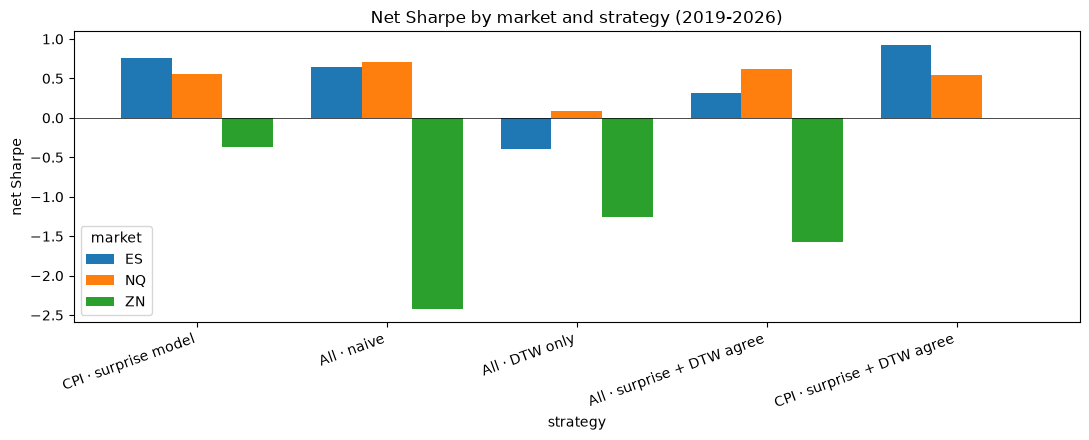

In [9]:
piv = perf["sharpe_net"].unstack("market")[list(MARKETS)].reindex(STRATS)
ax = piv.plot.bar(figsize=(11, 4.5), width=0.8)
ax.axhline(0, c="k", lw=0.5); ax.set_ylabel("net Sharpe"); ax.set_title("Net Sharpe by market and strategy (2019-2026)")
plt.xticks(rotation=20, ha="right"); plt.tight_layout()
plt.savefig(FIGURES_DIR / "nb07_sharpe_by_market.png", dpi=150); plt.show()

**How to read it.** `sharpe_gross` against `sharpe_net` shows how much each market loses to costs; ZN is expected to lose the most. `p_random_sign` below 0.05 means the direction is genuinely informative in that market.

### 5.1 Which releases earn money in each market? (All · naive)

In [10]:
fam_rows = []
for sym, r in results.items():
    p = su.build_positions(r["panel"][r["panel"]["admitted"]], r["hist"], "naive", "w1", MIN_TRAIN, THRESHOLD)
    f = su.per_family_stats(p, "w1")
    f["market"] = sym
    fam_rows.append(f.reset_index())
fam_tab = pd.concat(fam_rows)
fam_tab.to_csv(RESULTS_DIR / "nb07_per_family_by_market.csv", index=False)
display(fam_tab.pivot_table(index="family", columns="market", values="total_net_pct").round(2)
        .sort_values("ES", ascending=False))

market,ES,NQ,ZN
family,,,
CPI,4.330,6.040,-2.990
JOLTS,3.000,NaN,-0.540
Retail Sales,2.290,2.560,-4.460
U. of Michigan Sentiment,1.420,4.240,-1.830
Advance Goods Trade Balance,1.320,1.380,NaN
ISM Manufacturing,0.890,1.370,-2.030
Factory Orders,0.870,4.620,-1.040
Trade Balance,0.710,0.360,-0.620
Dallas Fed Manf. Activity,0.690,-1.210,NaN


### 5.2 Transaction costs by market

In [11]:
cost_rows = []
for sym, r in results.items():
    for ticks in [0, 1, 2, 4]:
        for s, t in ma.with_costs(r, ticks, COMMISSION_RT, MIN_TRAIN, THRESHOLD).items():
            pf = wf.performance(t, EVAL_START, EVAL_END, s)
            cost_rows.append(dict(market=sym, strategy=s, ticks_rt=ticks, sharpe_net=pf["sharpe_net"], avg_net_bps=pf["avg_net_bps"]))
cost_tab = pd.DataFrame(cost_rows)
cost_tab.to_csv(RESULTS_DIR / "nb07_cost_sensitivity.csv", index=False)
display(cost_tab.pivot_table(index="ticks_rt", columns=["strategy", "market"], values="sharpe_net").round(2))

strategy All · naive              CPI · surprise model             
market            ES    NQ     ZN                   ES    NQ     ZN
ticks_rt                                                           
0              1.090 0.820 -0.560                0.660 0.610  0.050
1              0.870 0.770 -1.490                0.600 0.590 -0.180
2              0.650 0.710 -2.420                0.760 0.550 -0.370
4              0.200 0.600 -4.240                0.610 0.540  0.000

## 6. Three-Market Portfolio

Each market's positions are scaled by an **equal-risk weight** (inverse volatility of its 30-minute release-window return over 2016–2018, ES = 1), then the markets are traded together.

In [12]:
weights = ma.risk_weights(results, HIST_START, EVAL_START)
print("Risk weights (contracts-equivalent per ES unit, history 2016-2018):")
display(weights.round(3).to_frame("weight"))

corr_tabs = {}
for s in ["All · naive", "CPI · surprise model"]:
    m = pd.DataFrame({sym: wf.monthly_returns(r["trades"][s], EVAL_START, EVAL_END) for sym, r in results.items()})
    corr_tabs[s] = m.corr()
    print(f"\nCorrelation of monthly net returns across markets — {s}:")
    display(corr_tabs[s].round(2))

PORT = {}
for s in STRATS:
    PORT[f"3-market · {s}"] = ma.portfolio(results, s, weights, f"3-market · {s}")
PORT["2-market (ES+NQ) · All · naive"] = ma.portfolio({k: results[k] for k in ["ES", "NQ"]}, "All · naive", weights, "2-market (ES+NQ) · All · naive")
PORT["2-market (ES+NQ) · CPI · surprise model"] = ma.portfolio({k: results[k] for k in ["ES", "NQ"]}, "CPI · surprise model", weights, "2-market (ES+NQ) · CPI · surprise model")

rows_q = []
for name, t in PORT.items():
    p = wf.performance(t, EVAL_START, EVAL_END, name)
    _, p_null = su.random_sign_pvalue(t, wf.monthly_returns, EVAL_START, EVAL_END, n=N_NULL)
    (lo, _, hi), _ = wf.bootstrap_sharpe(t, EVAL_START, EVAL_END, N_BOOT)
    rows_q.append(dict(portfolio=name, trades_per_year=p["trades"] / N_YEARS, avg_net_bps=p["avg_net_bps"],
                       total_net_pct=p["total_net_pct"], ann_return_pct=p["ann_return_pct"], ann_vol_pct=p["ann_vol_pct"],
                       sharpe_net=p["sharpe_net"], ci_5=lo, ci_95=hi,
                       sharpe_ex_2022=sharpe_m(t, EVAL_START, EVAL_END, 2022), max_dd_pct=p["max_dd_pct"], p_random_sign=p_null))
port_tab = pd.DataFrame(rows_q).set_index("portfolio")
port_tab.to_csv(RESULTS_DIR / "nb07_portfolio.csv")
pd.concat(PORT.values()).to_csv(RESULTS_DIR / "nb07_portfolio_trade_log.csv", index=False)
display(port_tab.round(3))

Risk weights (contracts-equivalent per ES unit, history 2016-2018):


,weight
ES,1.000
NQ,0.711
ZN,2.672



Correlation of monthly net returns across markets — All · naive:


,ES,NQ,ZN
ES,1.000,0.790,-0.130
NQ,0.790,1.000,-0.120
ZN,-0.130,-0.120,1.000



Correlation of monthly net returns across markets — CPI · surprise model:


,ES,NQ,ZN
ES,1.000,0.800,-0.020
NQ,0.800,1.000,-0.030
ZN,-0.020,-0.030,1.000


,trades_per_year,avg_net_bps,total_net_pct,ann_return_pct,ann_vol_pct,sharpe_net,ci_5,ci_95,sharpe_ex_2022,max_dd_pct,p_random_sign
portfolio,,,,,,,,,,,
3-market · CPI · surprise model,20.551,6.111,9.412,1.255,1.917,0.655,-0.063,1.356,-0.030,-3.779,0.019
3-market · All · naive,277.040,-1.428,-29.655,-3.954,5.241,-0.754,-1.511,-0.031,-1.166,-31.134,0.002
3-market · All · DTW only,182.825,-2.163,-29.638,-3.952,4.398,-0.898,-1.541,-0.260,-0.957,-31.396,0.088
3-market · All · surprise + DTW agree,145.193,-1.258,-13.691,-1.826,4.297,-0.425,-1.129,0.281,-0.721,-16.441,0.015
3-market · CPI · surprise + DTW agree,13.745,9.697,9.988,1.332,1.713,0.777,0.119,1.388,0.083,-2.350,0.009
2-market (ES+NQ) · All · naive,195.102,1.725,25.226,3.364,4.702,0.715,-0.007,1.435,0.376,-7.417,0.000
2-market (ES+NQ) · CPI · surprise model,20.418,6.449,9.867,1.316,1.914,0.687,-0.013,1.387,0.017,-3.297,0.023


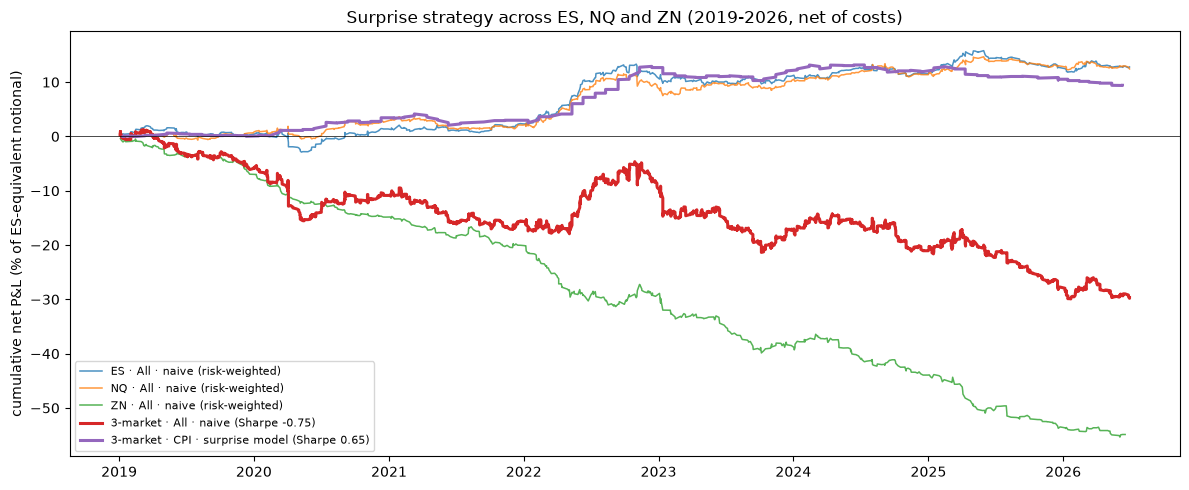

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
show = [("ES", "All · naive"), ("NQ", "All · naive"), ("ZN", "All · naive")]
for sym, s in show:
    cum, _ = wf.drawdown_series(results[sym]["trades"][s], EVAL_START, EVAL_END)
    ax.plot(cum.index, cum.values * weights[sym], lw=1.1, alpha=0.8, label=f"{sym} · {s} (risk-weighted)")
for name in ["3-market · All · naive", "3-market · CPI · surprise model"]:
    cum, _ = wf.drawdown_series(PORT[name], EVAL_START, EVAL_END)
    ax.plot(cum.index, cum.values, lw=2.2, label=f"{name} (Sharpe {port_tab.loc[name, 'sharpe_net']:.2f})")
ax.axhline(0, c="k", lw=0.5); ax.set_ylabel("cumulative net P&L (% of ES-equivalent notional)")
ax.set_title("Surprise strategy across ES, NQ and ZN (2019-2026, net of costs)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "nb07_portfolio_cumulative.png", dpi=150); plt.show()

### 6.1 Peer-format metrics for the portfolios (daily, vs ES buy-and-hold)

In [14]:
daily_close = sc.build_daily_close(adj_by["ES"])
days = daily_close.index[(daily_close.index >= pd.Timestamp(EVAL_START)) & (daily_close.index <= pd.Timestamp(EVAL_END))]
bh = wf.buy_hold_daily(daily_close, days)
peer = pd.DataFrame({name: wf.peer_metrics(wf.daily_returns(t, days), bh, trades_per_year=port_tab.loc[name, "trades_per_year"])
                     for name, t in PORT.items()}).T
peer.to_csv(RESULTS_DIR / "nb07_portfolio_peer_metrics.csv")
display(peer.round(3))

,total_pct,vol_pct,sharpe,max_dd_pct,beta,corr,trades_per_year
3-market · CPI · surprise model,9.412,1.966,0.656,-3.750,-0.002,-0.022,20.551
3-market · All · naive,-29.568,5.791,-0.700,-31.352,0.006,0.021,277.040
3-market · All · DTW only,-27.446,4.668,-0.806,-29.204,0.005,0.023,182.825
3-market · All · surprise + DTW agree,-13.427,4.366,-0.422,-16.075,0.003,0.015,145.193
3-market · CPI · surprise + DTW agree,9.988,1.770,0.774,-2.194,-0.004,-0.047,13.745
2-market (ES+NQ) · All · naive,25.464,4.655,0.750,-7.417,0.002,0.007,195.102
2-market (ES+NQ) · CPI · surprise model,9.867,1.967,0.688,-3.295,-0.002,-0.021,20.418


## 7. Final Comparison

In [15]:
rows_f = []
for sym in MARKETS:
    for s in ["CPI · surprise model", "All · naive", "All · surprise + DTW agree", "All · DTW only"]:
        r = perf.loc[(sym, s)]
        rows_f.append(dict(book=f"{sym} · {s}", trades_per_year=r.trades_per_year, net_bps_per_trade=r.avg_net_bps,
                           sharpe_net=r.sharpe_net, sharpe_ex_2022=r.sharpe_ex_2022, max_dd_pct=r.max_dd_pct,
                           p_random_sign=r.p_random_sign))
for name in PORT:
    r = port_tab.loc[name]
    rows_f.append(dict(book=name, trades_per_year=r.trades_per_year, net_bps_per_trade=r.avg_net_bps,
                       sharpe_net=r.sharpe_net, sharpe_ex_2022=r.sharpe_ex_2022, max_dd_pct=r.max_dd_pct,
                       p_random_sign=r.p_random_sign))
rows_f += [
    dict(book="Peer: Jack DTW, ES only (slide, 2018-26)", trades_per_year=185, net_bps_per_trade=1.18, sharpe_net=0.613, max_dd_pct=-4.928),
    dict(book="Peer: Jack DTW, ES/NQ/ZN combined (README test 2021-26, quarter tick)", sharpe_net=-0.19),
]
final = pd.DataFrame(rows_f).set_index("book")
final.to_csv(RESULTS_DIR / "nb07_final_comparison.csv")
display(final.round(3))

,trades_per_year,net_bps_per_trade,sharpe_net,sharpe_ex_2022,max_dd_pct,p_random_sign
book,,,,,,
ES · CPI · surprise model,8.941,8.228,0.756,0.049,-2.035,0.006
ES · All · naive,98.352,1.736,0.647,0.275,-4.836,0.000
ES · All · surprise + DTW agree,52.579,1.138,0.313,0.067,-4.612,0.030
ES · All · DTW only,64.589,-1.454,-0.389,-0.322,-11.004,0.479
NQ · CPI · surprise model,11.477,7.120,0.554,-0.014,-2.743,0.047
NQ · All · naive,96.751,2.412,0.712,0.439,-5.662,0.005
NQ · All · surprise + DTW agree,50.844,3.107,0.621,0.588,-6.716,0.021
NQ · All · DTW only,63.121,0.345,0.083,0.171,-8.282,0.271
ZN · CPI · surprise model,0.133,-17.033,-0.365,-0.392,-0.170,1.000


### 7.1 Automatic summary

In [16]:
print("=" * 110)
print("NOTEBOOK 07 SUMMARY — surprise and DTW on ES, NQ, ZN (2019-2026, net of costs)")
print("=" * 110)
for sym in MARKETS:
    print(f"\n{sym} ({ma.SPECS[sym]['name']}), median cost {results[sym]['px']['cost_bps'].median():.2f} bps:")
    for s in STRATS:
        r = perf.loc[(sym, s)]
        print(f"  {s:<30s} {r.trades_per_year:5.0f} tr/yr | {r.avg_net_bps:6.2f} bps | Sharpe gross {r.sharpe_gross:5.2f} "
              f"net {r.sharpe_net:5.2f} | ex-2022 {r.sharpe_ex_2022:5.2f} | random-sign p {r.p_random_sign:.3f}")
print("\nPortfolios (equal risk, weights " + ", ".join(f"{k} {v:.2f}" for k, v in weights.items()) + "):")
for name, r in port_tab.iterrows():
    print(f"  {name:<42s} {r.trades_per_year:5.0f} tr/yr | Sharpe {r.sharpe_net:5.2f} [{r.ci_5:.2f}, {r.ci_95:.2f}] | "
          f"ex-2022 {r.sharpe_ex_2022:5.2f} | maxDD {r.max_dd_pct:6.2f}% | random-sign p {r.p_random_sign:.3f}")

NOTEBOOK 07 SUMMARY — surprise and DTW on ES, NQ, ZN (2019-2026, net of costs)

ES (E-mini S&P 500), median cost 1.57 bps:
  CPI · surprise model               9 tr/yr |   8.23 bps | Sharpe gross  0.88 net  0.76 | ex-2022  0.05 | random-sign p 0.006
  All · naive                       98 tr/yr |   1.74 bps | Sharpe gross  1.17 net  0.65 | ex-2022  0.28 | random-sign p 0.000
  All · DTW only                    65 tr/yr |  -1.45 bps | Sharpe gross -0.01 net -0.39 | ex-2022 -0.32 | random-sign p 0.479
  All · surprise + DTW agree        53 tr/yr |   1.14 bps | Sharpe gross  0.70 net  0.31 | ex-2022  0.07 | random-sign p 0.030
  CPI · surprise + DTW agree         7 tr/yr |  12.50 bps | Sharpe gross  1.02 net  0.93 | ex-2022  0.21 | random-sign p 0.000

NQ (E-mini Nasdaq-100), median cost 0.61 bps:
  CPI · surprise model              11 tr/yr |   7.12 bps | Sharpe gross  0.60 net  0.55 | ex-2022 -0.01 | random-sign p 0.047
  All · naive                       97 tr/yr |   2.41 bps | Sharpe g

## 8. Interpretation and Conclusion

*Fill this in after running, using the summary above. Suggested structure:*

**1. Does the surprise work outside ES?** Compare NQ and ZN with ES, gross and net. Does ZN survive its costs?

**2. Are the directions right?** Section 3.2: do the markets react to CPI and payrolls in the expected directions?

**3. Does DTW help in any market?**

**4. Does the three-market portfolio help?** Trades per year, Sharpe, drawdown, and the correlation between markets.

**5. Recommendation:** which markets and which strategy, compared with the peer's ES-only and multi-asset DTW books.